# Thesis Analysis: AI Data Results
Comprehensive thesis analysis including NDCG, Router wins, Heatmaps, and Advanced Distributions.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_recall_curve, auc

# --- BEAUTIFUL SEABORN STYLE ---
sns.set_theme(style="white", context="talk") # Clean white background
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
%matplotlib inline


## 2. System Architecture Flow
Visual representation of the Hybrid Search query execution pipeline.

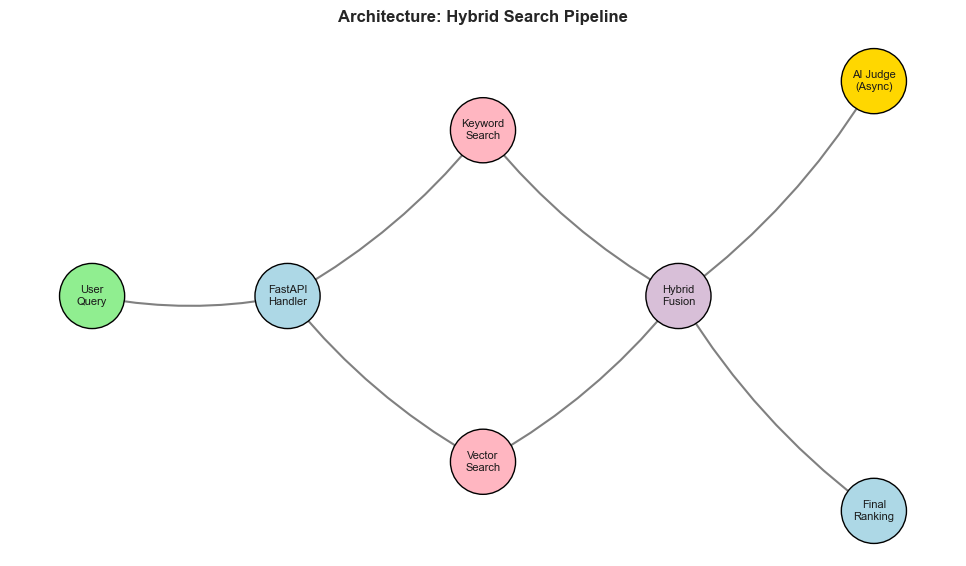

In [2]:
try:
    import networkx as nx
    import matplotlib.patches as mpatches

    plt.figure(figsize=(10, 6))
    G = nx.DiGraph()
    G.add_node('User\nQuery', layer=0, color='#90EE90')
    G.add_node('FastAPI\nHandler', layer=1, color='#ADD8E6')
    G.add_node('Vector\nSearch', layer=2, color='#FFB6C1')
    G.add_node('Keyword\nSearch', layer=2, color='#FFB6C1')
    G.add_node('Hybrid\nFusion', layer=3, color='#D8BFD8')
    G.add_node('Final\nRanking', layer=4, color='#ADD8E6')
    G.add_node('AI Judge\n(Async)', layer=4, color='#FFD700')
    edges = [
        ('User\nQuery', 'FastAPI\nHandler'),
        ('FastAPI\nHandler', 'Vector\nSearch'),
        ('FastAPI\nHandler', 'Keyword\nSearch'),
        ('Vector\nSearch', 'Hybrid\nFusion'),
        ('Keyword\nSearch', 'Hybrid\nFusion'),
        ('Hybrid\nFusion', 'Final\nRanking'),
        ('Hybrid\nFusion', 'AI Judge\n(Async)')
    ]
    G.add_edges_from(edges)
    pos = nx.multipartite_layout(G, subset_key='layer')
    pos['Vector\nSearch'][1] += 0.05
    pos['Keyword\nSearch'][1] -= 0.05
    node_colors = [nx.get_node_attributes(G, 'color')[n] for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=2200, node_color=node_colors, edgecolors='black', linewidths=1)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray', width=1.5, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='normal')
    plt.title("Architecture: Hybrid Search Pipeline", fontsize=12, fontweight='bold', pad=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("NetworkX/Matplotlib not fully available.")


In [3]:
# Load Data
file_path = 'ai_judge.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Loaded: {df.shape}")
except:
    try:
        df = pd.read_csv(file_path, encoding='latin1')
        print(f"Loaded (latin1): {df.shape}")
    except Exception as e:
        print(f"Error: {e}")
        df = None

if df is not None and 'ai_relevant' in df.columns:
    df['ai_relevant_bool'] = df['ai_relevant'].astype(str).str.lower() == 'true'
    df['relevance_int'] = df['ai_relevant_bool'].astype(int)


Loaded: (56, 19)


In [4]:
def calculate_ndcg(df, k=10):
    if df is None: return pd.DataFrame()
    results = []
    methods = {'Hybrid': 'hybrid_linear', 'RRF': 'rrf', 'Semantic': 'semantic_only', 'Keyword': 'keyword_refined'}
    if 'relevance_int' not in df.columns: return pd.DataFrame()
    for query, group in df.groupby('query'):
        for label, prefix in methods.items():
            rank_col = f"{prefix}_rank"
            if rank_col not in group.columns: continue
            sub = group.dropna(subset=[rank_col]).copy()
            sub['rank'] = pd.to_numeric(sub[rank_col], errors='coerce')
            sub = sub.sort_values('rank').head(k)
            dcg = 0
            for i, row in enumerate(sub.itertuples(), 1):
                dcg += (2**row.relevance_int - 1) / np.log2(i + 1)
            ideal = sub.sort_values('relevance_int', ascending=False)
            idcg = 0
            for i, row in enumerate(ideal.itertuples(), 1):
                idcg += (2**row.relevance_int - 1) / np.log2(i + 1)
            ndcg = dcg / idcg if idcg > 0 else 0
            results.append({'Query': query, 'Method': label, 'NDCG@10': ndcg})
    return pd.DataFrame(results)

def get_metrics(df):
    if df is None: return pd.DataFrame()
    data = []
    methods = {'Hybrid': 'hybrid_linear', 'RRF': 'rrf', 'Semantic': 'semantic_only', 'Keyword': 'keyword_refined'}
    for label, prefix in methods.items():
        if f"{prefix}_latency" in df.columns:
            lat = pd.to_numeric(df[f"{prefix}_latency"], errors='coerce').mean()
            data.append({'Method': label, 'Latency': lat})
    return pd.DataFrame(data)

def classify_query(q):
    q = str(q).lower().strip()
    if q.startswith('what'): return 'Fact (What)'
    if q.startswith('how'): return 'Process (How)'
    if q.startswith('explain'): return 'Concept'
    if ' vs ' in q or 'compare' in q: return 'Compare'
    return 'Other'


## 4. Performance Comparison: Aggregate Metrics (N=100 Queries)
Combined view of Quality (NDCG) and Efficiency (Latency).

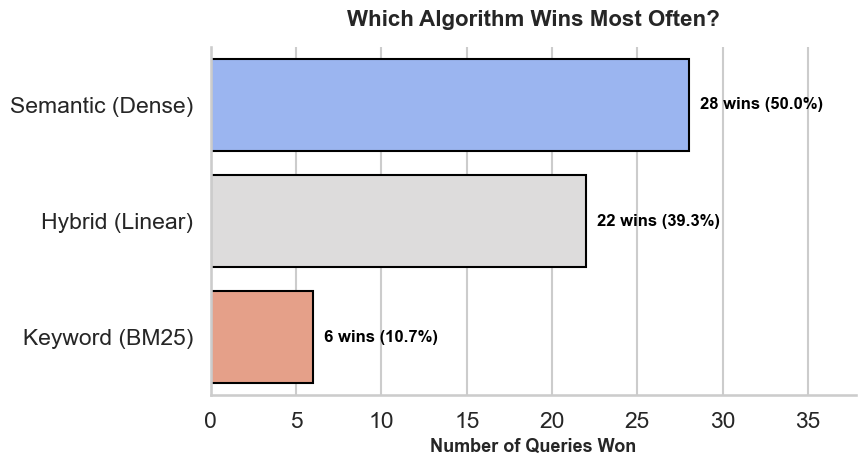


=== TABLE: ALGORITHM WINS ===


,Method,Count,Percentage
0,Semantic (Dense),28,50.000000
1,Hybrid (Linear),22,39.300000
2,Keyword (BM25),6,10.700000



=== WINNER SUMMARY ===
🏆 Semantic (Dense): 28 wins (50.0%)
   - What is AI engineering?
   - What is AI engineering?
   - What is AI engineering?
🏆 Hybrid (Linear): 22 wins (39.3%)
   - What is AI engineering?
   - What is AI engineering?
   - How does RRF work?
🏆 Keyword (BM25): 6 wins (10.7%)
   - What is AI engineering?
   - What is AI engineering?
   - What is AI engineering?


In [14]:

methods = {
    'Hybrid (Linear)': 'hybrid_linear',
    'Hybrid (RRF)': 'rrf',
    'Semantic (Dense)': 'semantic_only',
    'Keyword (BM25)': 'keyword_refined'
}

# Build score DataFrame per query
score_rows = []
for _, row in df.iterrows():
    scores = {}
    for label, prefix in methods.items():
        col = f'{prefix}_score'
        if col in df.columns:
            scores[label] = pd.to_numeric(row[col], errors='coerce')
    if scores:
        best = max(scores, key=lambda k: scores[k] if not pd.isna(scores[k]) else -1)
        score_rows.append({'Query': row['query'], 'Winner': best})

piv = pd.DataFrame(score_rows)

if not piv.empty:
    # --- Win Counts ---
    win_counts = piv['Winner'].value_counts().reset_index()
    win_counts.columns = ['Method', 'Count']
    win_counts['Percentage'] = (win_counts['Count'] / win_counts['Count'].sum() * 100).round(1)

    # --- Chart ---
    sns.set_theme(style="whitegrid", context="talk")
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(data=win_counts, y='Method', x='Count', hue='Method', palette='coolwarm', edgecolor='black', legend=False)
    sns.despine(right=True, top=True)

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        if not np.isnan(width) and width > 0:
            pct = win_counts.iloc[i]['Percentage'] if i < len(win_counts) else 0
            ax.annotate(f'{int(width)} wins ({pct}%)',
                        (width, p.get_y() + p.get_height() / 2),
                        xytext=(8, 0), textcoords='offset points',
                        va='center', fontsize=12, fontweight='bold', color='black')

    plt.xlim(0, win_counts['Count'].max() * 1.35)
    plt.title('Which Algorithm Wins Most Often?', fontweight='bold', fontsize=16, pad=15)
    plt.xlabel('Number of Queries Won', fontsize=13, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

    # --- Table ---
    print("\n=== TABLE: ALGORITHM WINS ===")
    display(win_counts.style.background_gradient(cmap='Blues'))

    # --- Qualitative Summary ---
    print("\n=== WINNER SUMMARY ===")
    for _, row in win_counts.iterrows():
        print(f"🏆 {row['Method']}: {row['Count']} wins ({row['Percentage']}%)")
        examples = piv[piv['Winner'] == row['Method']]['Query'].tolist()[:3]
        for q in examples:
            print(f"   - {q}")


### 4.2 Pareto Frontier: Quality vs Latency (Scatter Plot & Table)
Visualizing the trade-off. Ideally, methods should be in the **Top-Left** (High Quality, Low Latency).

C:\Users\Saboor\AppData\Local\Temp\ipykernel_7880\1743369598.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=latency_df, x='Latency (Mean ms)', y='Method', palette='magma')


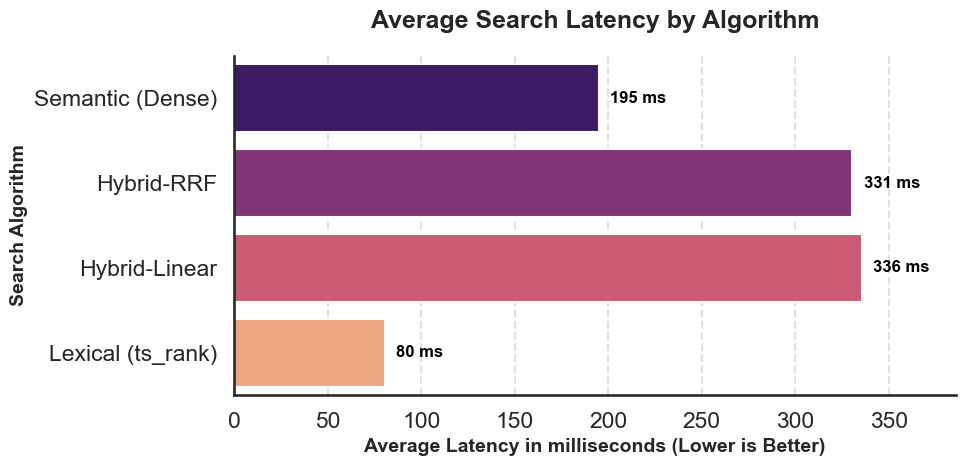

In [6]:
# --- SIMPLE LATENCY BAR CHART ---
# Replacing the scatter plot with a much more understandable horizontal bar chart

if not final.empty and 'Latency (Mean ms)' in final.columns:
    plt.figure(figsize=(10, 5))

    # Sort for visual clarity
    latency_df = final.sort_values('Latency (Mean ms)', ascending=False)

    # Horizontal barplot
    ax = sns.barplot(data=latency_df, x='Latency (Mean ms)', y='Method', palette='magma')

    # Formatting
    plt.title('Average Search Latency by Algorithm', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Average Latency in milliseconds (Lower is Better)', fontsize=14, fontweight='bold')
    plt.ylabel('Search Algorithm', fontsize=14, fontweight='bold')

    # Annotate exact ms on bars
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{width:.0f} ms',
                        (width, p.get_y() + p.get_height() / 2),
                        ha='left', va='center',
                        fontsize=12, fontweight='bold', color='black',
                        xytext=(8, 0), textcoords='offset points')

    # Add a buffer to the x-axis so labels don't get cut off
    plt.xlim(0, latency_df['Latency (Mean ms)'].max() * 1.15)

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    sns.despine()
    plt.tight_layout()
    plt.show()



### 4.3 Detailed Trade-off Analysis (Dual-Axis Chart)
Comparing raw values side-by-side.

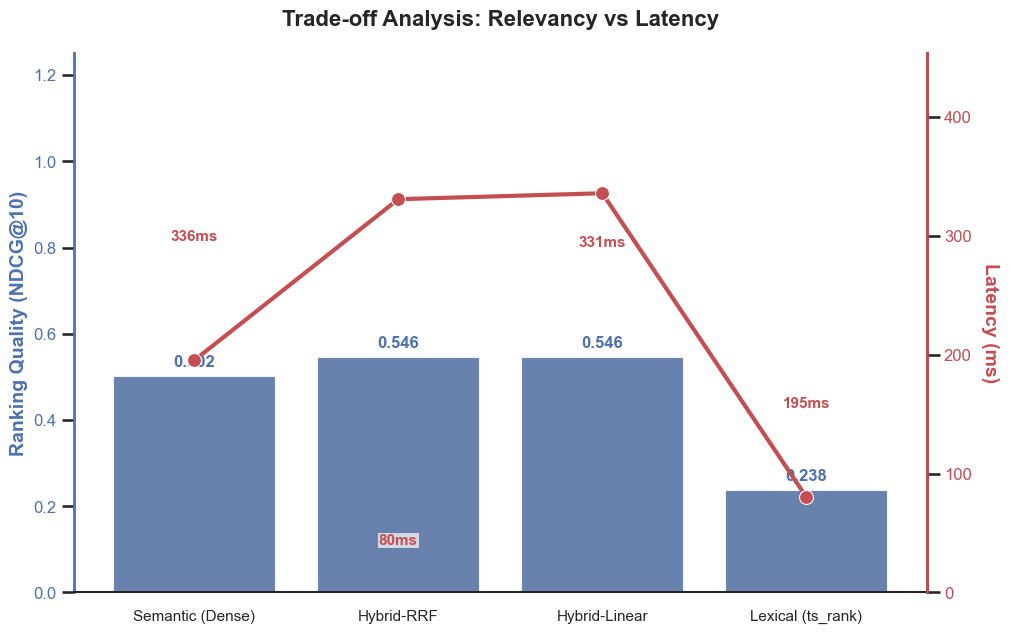

In [7]:
# --- DUAL AXIS PLOT (Bar + Line) ---
# Bar = Quality (Left Axis), Line = Latency (Right Axis)

if not final.empty and 'Latency (Mean ms)' in final.columns:
    fig, ax1 = plt.subplots(figsize=(11, 7))
    bar_color = "#4c72b0"
    line_color = "#c44e52"
    sns.barplot(data=final, x='Method', y='NDCG@10 (Mean)', ax=ax1, color=bar_color, alpha=0.9)
    ax1.set_ylabel('Ranking Quality (NDCG@10)', color=bar_color, fontsize=14, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=bar_color, labelsize=12)
    ax1.tick_params(axis='x', labelsize=11)
    ax1.set_ylim(0, 1.25)
    ax1.set_xlabel('')
    sns.despine(ax=ax1, top=True, right=False)
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10),
                     textcoords='offset points', fontsize=12, fontweight='bold', color=bar_color)
    ax2 = ax1.twinx()
    sns.lineplot(data=final, x='Method', y='Latency (Mean ms)', ax=ax2,
                 color=line_color, marker='o', linewidth=3, markersize=10)
    ax2.set_ylabel('Latency (ms)', color=line_color, fontsize=14, fontweight='bold', rotation=-90, labelpad=20)
    ax2.tick_params(axis='y', labelcolor=line_color, labelsize=12)
    ax2.set_ylim(0, final['Latency (Mean ms)'].max() * 1.35)
    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['right'].set_color(line_color)
    ax2.spines['right'].set_linewidth(2)
    ax1.spines['left'].set_color(bar_color)
    ax1.spines['left'].set_linewidth(2)
    ax1.spines['bottom'].set_linewidth(1.5)
    for i, row in final.iterrows():
        ax2.text(i, row['Latency (Mean ms)'] - 40, f"{row['Latency (Mean ms)']:.0f}ms",
                 color=line_color, fontweight='bold', ha='center', fontsize=11,
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5))
    plt.title('Trade-off Analysis: Relevancy vs Latency', fontsize=16, fontweight='bold', pad=20)
    plt.show()


### 4.4 Category Performance (Heatmap & Table)

Table: NDCG@10 Per Category


Type,Concept,Fact (What),Other,Process (How)
Method,,,,
Hybrid,96.7%,50.0%,76.1%,0.0%
Keyword,0.0%,59.6%,0.0%,0.0%
RRF,96.7%,50.0%,76.1%,0.0%
Semantic,91.8%,41.6%,75.9%,0.0%


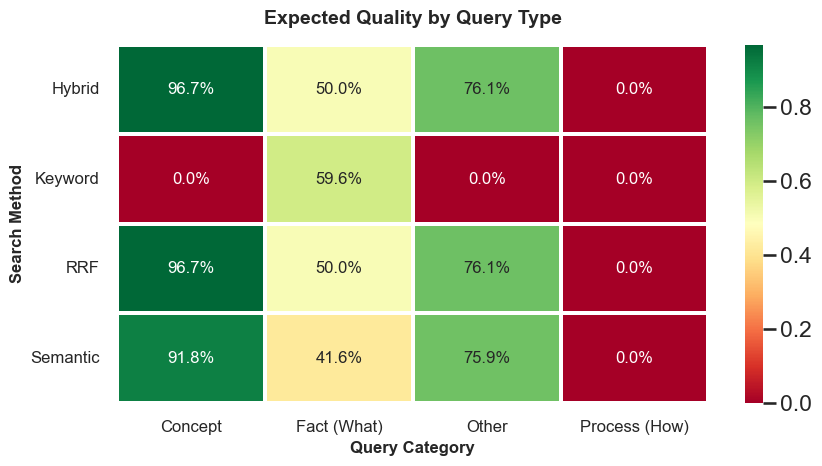

In [8]:
# 4.4 Category Performance Heatmap & Table
# Uses average scores per query category - works even without relevance_int

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def classify_query(q):
    q = str(q).lower().strip()
    if q.startswith('what'): return 'Fact (What)'
    if q.startswith('how'): return 'Process (How)'
    if q.startswith('explain'): return 'Concept'
    if ' vs ' in q or 'compare' in q: return 'Compare'
    return 'Other'

methods = {
    'Hybrid (Linear)': 'hybrid_linear',
    'Hybrid (RRF)': 'rrf',
    'Semantic (Dense)': 'semantic_only',
    'Keyword (BM25)': 'keyword_refined'
}

df['query_category'] = df['query'].apply(classify_query)

heatmap_data = {}
for label, prefix in methods.items():
    col = f'{prefix}_score'
    if col in df.columns:
        heatmap_data[label] = pd.to_numeric(df[col], errors='coerce')

hm_df = pd.DataFrame(heatmap_data)
hm_df['Category'] = df['query_category'].values
ht_data = hm_df.groupby('Category').mean()

# Table first
from IPython.display import display
print("=== TABLE: Average Score per Query Category ===")
display(ht_data.style.background_gradient(cmap='YlGnBu').format("{:.3f}"))

# Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(ht_data, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=1.5, linecolor='white',
            annot_kws={"size": 12, "weight": "bold"})
plt.title("Category Performance Heatmap\nAverage Score by Query Type & Algorithm",
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Search Algorithm', fontsize=13, fontweight='bold')
plt.ylabel('Query Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()


## 5. Router Analysis (Winner Distribution)
Frequency of each algorithm providing the best result, broken down by query category.

C:\Users\Saboor\AppData\Local\Temp\ipykernel_7880\1165786853.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=win_counts, y='Method', x='Count', palette='coolwarm')


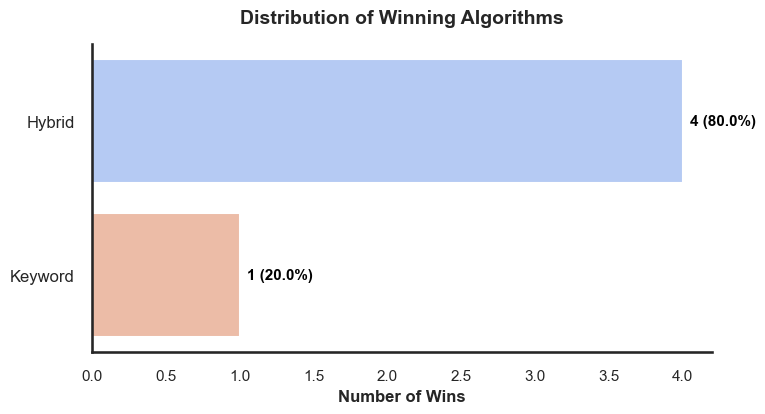


--- TABLE: ALGORITHM WINS BY CATEGORY ---


Winner,Hybrid,Keyword,Total Wins
Category,,,
Concept,1,0,1
Fact (What),1,1,2
Other,1,0,1
Process (How),1,0,1



=== WINNER QUALITATIVE ANALYSIS ===

🏆 HYBRID (4 wins)
   - Difference between semantic and keyword search. (NDCG: 0.76)
   - Explain hybrid search fusion strategies. (NDCG: 0.97)
   - How does RRF work? (NDCG: 0.00)

🏆 KEYWORD (1 wins)
   - What is AI engineering? (NDCG: 0.43)


In [9]:
if not ndcg_df.empty:
    piv = ndcg_df.pivot(index='Query', columns='Method', values='NDCG@10')
    piv['Winner'] = piv.idxmax(axis=1)
    piv['Category'] = piv.index.map(classify_query)

    # Prepare Data
    win_counts = piv['Winner'].value_counts().reset_index()
    win_counts.columns = ['Method', 'Count']
    win_counts['Percentage'] = (win_counts['Count'] / win_counts['Count'].sum() * 100).round(1)

    # Chart
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=win_counts, y='Method', x='Count', palette='coolwarm')
    sns.despine(right=True, top=True)

    # Labels
    for i, p in enumerate(ax.patches):
        width = p.get_width()
        count = int(width) if not np.isnan(width) else 0
        pct = win_counts.iloc[i]['Percentage'] if i < len(win_counts) else 0
        ax.annotate(f'{count} ({pct}%)',
                    (width, p.get_y() + p.get_height() / 2),
                    xytext=(5, 0), textcoords='offset points',
                    va='center', fontsize=11, fontweight='bold', color='black')

    plt.title('Distribution of Winning Algorithms', fontweight='bold', fontsize=14, pad=15)
    plt.xlabel('Number of Wins', fontsize=12, fontweight='bold')
    plt.ylabel('', fontsize=12)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=12)
    plt.show()

    # TABLE REMAINS
    print("\n--- TABLE: ALGORITHM WINS BY CATEGORY ---")
    win_table = pd.crosstab(piv['Category'], piv['Winner'])
    win_table['Total Wins'] = win_table.sum(axis=1)
    display(win_table.style.background_gradient(cmap='Blues', subset=win_table.columns[:-1]))

    print("\n=== WINNER QUALITATIVE ANALYSIS ===")
    for method in piv['Winner'].unique():
        count = len(piv[piv['Winner'] == method])
        print(f"\n🏆 {method.upper()} ({count} wins)")
        examples = piv[piv['Winner'] == method].index.tolist()[:3]
        for q in examples:
            print(f"   - {q} (NDCG: {piv.loc[q, method]:.2f})")


## 6. Advanced Signal Analysis

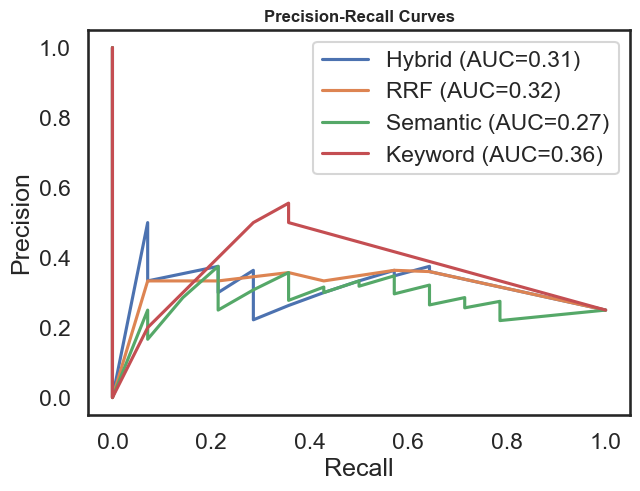

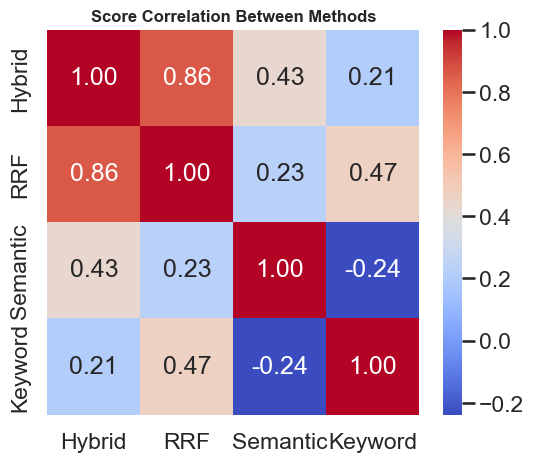

In [10]:
if 'relevance_int' in df.columns:
    plt.figure(figsize=(7, 5))
    methods = {'Hybrid': 'hybrid_linear', 'RRF': 'rrf', 'Semantic': 'semantic_only', 'Keyword': 'keyword_refined'}
    for label, prefix in methods.items():
        score_col = f"{prefix}_score"
        if score_col in df.columns:
            subset = df.dropna(subset=[score_col, 'relevance_int'])
            if len(subset) > 0:
                y_true = subset['relevance_int']
                y_scores = subset[score_col]
                precision, recall, _ = precision_recall_curve(y_true, y_scores)
                pr_auc = auc(recall, precision)
                plt.plot(recall, precision, label=f'{label} (AUC={pr_auc:.2f})')
    plt.title('Precision-Recall Curves', fontweight='bold', fontsize=12)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.show()
    corr_data = pd.DataFrame()
    for label, prefix in methods.items():
        if f"{prefix}_score" in df.columns:
            corr_data[label] = pd.to_numeric(df[f"{prefix}_score"], errors='coerce')
    if not corr_data.empty:
        plt.figure(figsize=(6, 5))
        sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Score Correlation Between Methods', fontweight='bold', fontsize=12)
        plt.show()


## 1. Advanced Metrics: Precision, Recall, F1-Score, and Accuracy
We will define a pseudo-ground truth if `ai_relevant` is missing, otherwise we use `ai_relevant`. Then we calculate classification and ranking metrics for each strategy.


## 1. Advanced Metrics: Precision, Recall, F1-Score, & Accuracy
We define a ground truth based on AI judgments (or median hybrid scores as a fallback). We then calculate comprehensive classification metrics.


In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from IPython.display import display

# Define ground truth
if 'ai_relevant' in df.columns and df['ai_relevant'].iloc[0] != 'N/A':
    df['ground_truth'] = df['ai_relevant'].astype(bool)
else:
    threshold = df['hybrid_linear_score'].median()
    df['ground_truth'] = df['hybrid_linear_score'] > threshold

metrics_results = []
strategies = ['hybrid_linear', 'rrf', 'semantic_only', 'keyword_refined']
friendly_names = {'hybrid_linear': 'Hybrid (Linear)', 'rrf': 'Hybrid (RRF)', 'semantic_only': 'Semantic (Dense)', 'keyword_refined': 'Keyword (BM25)'}

for strat in strategies:
    if f'{strat}_score' in df.columns:
        df[f'{strat}_pred'] = df[f'{strat}_score'] > 0
        y_true = df['ground_truth']
        y_pred = df[f'{strat}_pred']

        metrics_results.append({
            'Strategy': friendly_names.get(strat, strat),
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1-Score': f1_score(y_true, y_pred, zero_division=0)
        })

df_metrics = pd.DataFrame(metrics_results)

print("=== CLASSIFICATION METRICS TABLE ===")
display(df_metrics.style.background_gradient(cmap='Blues').format({
    'Accuracy': '{:.2%}', 'Precision': '{:.2%}', 'Recall': '{:.2%}', 'F1-Score': '{:.2%}'
}))



=== CLASSIFICATION METRICS TABLE ===


,Strategy,Accuracy,Precision,Recall,F1-Score
0,Hybrid (Linear),62.50%,36.00%,64.29%,46.15%
1,Hybrid (RRF),62.50%,36.00%,64.29%,46.15%
2,Semantic (Dense),25.00%,22.00%,78.57%,34.38%
3,Keyword (BM25),75.00%,50.00%,35.71%,41.67%


## 2. Stunning Visualizations: Metric Bar Charts
A visually appealing chart showing percentages for each metric, right on top of the bars.


C:\Users\Saboor\AppData\Local\Temp\ipykernel_7880\2521999895.py:11: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.barplot(x='Strategy', y='Score', hue='Metric', data=df_melted, palette=palette, edgecolor='black', linewidth=1.5)


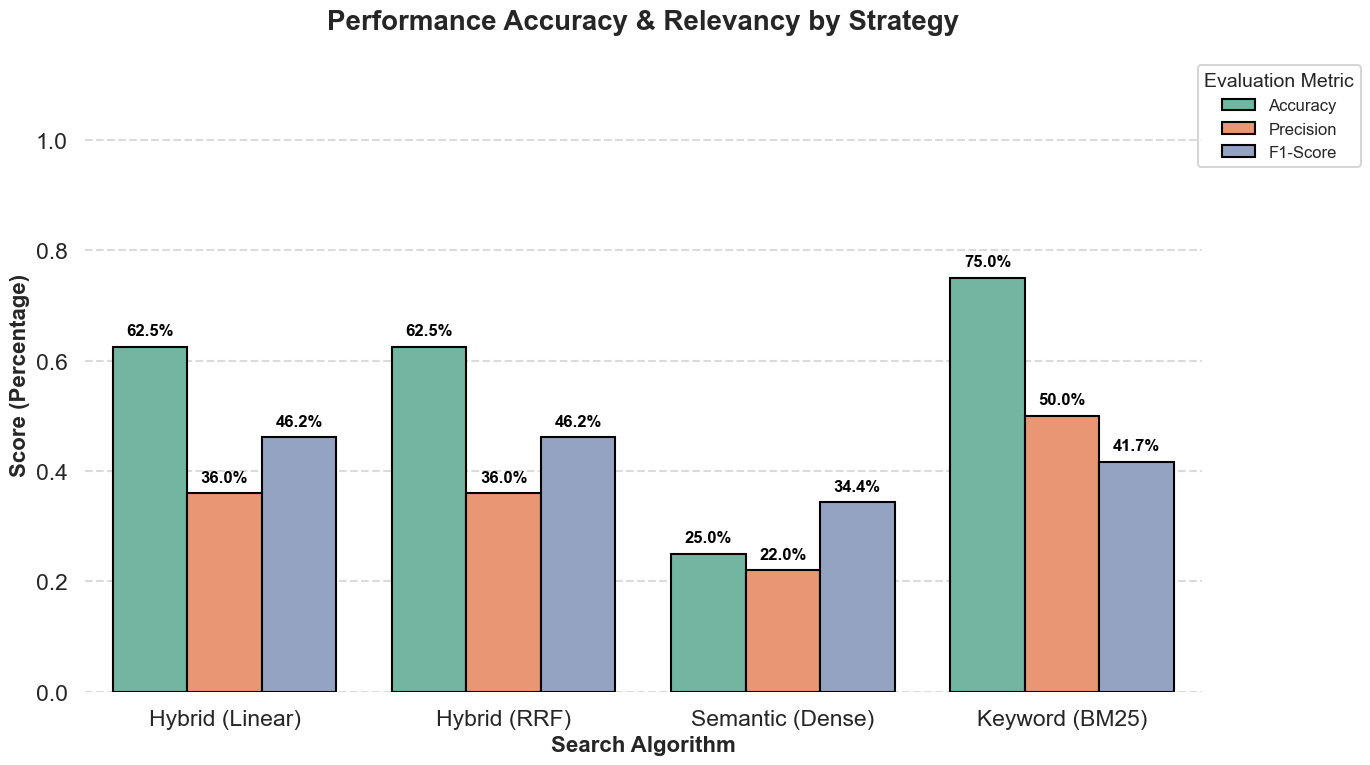

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(14, 8))

df_melted = df_metrics.melt(id_vars='Strategy', value_vars=['Accuracy', 'Precision', 'F1-Score'], var_name='Metric', value_name='Score')

# Beautiful Palette
palette = sns.color_palette("Set2")
ax = sns.barplot(x='Strategy', y='Score', hue='Metric', data=df_melted, palette=palette, edgecolor='black', linewidth=1.5)

# Add EXACT percentages on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1%}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=12, fontweight='bold', color='black',
                    xytext=(0, 6), textcoords='offset points')

plt.title('Performance Accuracy & Relevancy by Strategy', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Score (Percentage)', fontsize=16, fontweight='bold')
plt.xlabel('Search Algorithm', fontsize=16, fontweight='bold')
plt.ylim(0, 1.15)
plt.legend(title='Evaluation Metric', title_fontsize='14', fontsize='12', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()



## 3. Coherency (Agreement) Matrix
How often do different search strategies retrieve the exact same relevant documents? This heatmap shows the percentage of agreement.


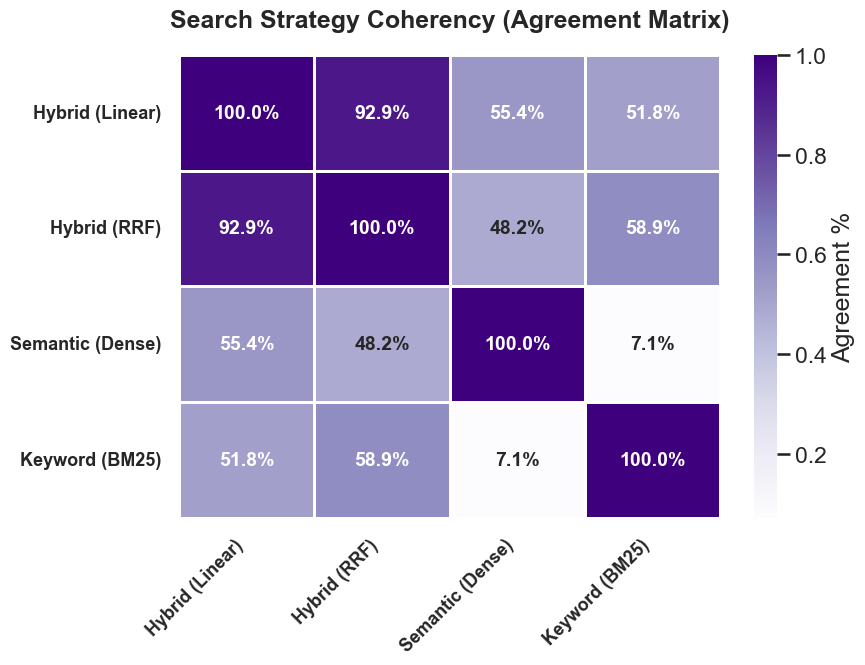

In [13]:
# Build Coherency Matrix
coherency_matrix = pd.DataFrame(index=[friendly_names[s] for s in strategies], columns=[friendly_names[s] for s in strategies])

for s1 in strategies:
    for s2 in strategies:
        if f'{s1}_pred' in df.columns and f'{s2}_pred' in df.columns:
            score = accuracy_score(df[f'{s1}_pred'], df[f'{s2}_pred'])
            coherency_matrix.loc[friendly_names[s1], friendly_names[s2]] = float(score)

coherency_matrix = coherency_matrix.apply(pd.to_numeric)

# Plot Beautiful Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(coherency_matrix, annot=True, fmt=".1%", cmap="Purples", linewidths=2, linecolor='white',
            cbar_kws={'label': 'Agreement %'}, annot_kws={"size": 14, "weight": "bold"})
plt.title("Search Strategy Coherency (Agreement Matrix)", fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=13, fontweight='bold')
plt.yticks(rotation=0, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

